In [58]:
import MDSplus as mds
import numpy as np
import matplotlib.pyplot as plt

In [59]:
def channel_load(shot: int, no: str, servidor: str = "tcabrcl.if.usp.br:8000"):
     """Reads a channel in the MDSplus tree from TCABR and returns (time, signal)."""
     
     conn = mds.Connection(servidor)
     conn.openTree("tcabr_shot", shot)
     sinal = conn.get(no).data()
     tempo = conn.get(f"dim_of({no})").data()
     conn.closeTree("tcabr_shot", shot)
     
     return tempo, sinal

def channel_character(shot: int, no: str):
     """Returns a dictionary with the channel's characteristics."""

     conn = mds.Connection("tcabrcl.if.usp.br:8000")
     conn.openTree("tcabr_shot", shot)
     info = {"no": no}

     try:
          sinal = conn.get(no + ".signal").data()
          info["n_points"] = len(sinal)
     except Exception as e:
          info["erro_sinal"] = str(e)
          return info

     try:
          tempo = conn.get(f"dim_of({no}.signal)").data()
          info["time"] = tempo

          if len(tempo) > 1:
               dt = np.median(np.diff(tempo))
               info["dt"] = dt
               info["frequence"] = 1.0 / dt
               info["duration"] = tempo[-1] - tempo[0]
     except Exception as e:
          info["erro_tempo"] = str(e)

     try:
          info["signalname"] = conn.get(no + ".signalname").data()
     except:
          info["signalname"] = None

     try:
        info["sigunit"] = conn.get(
            no + ".sigunit"
        ).data()
     except:
        info["sigunit"] = None

     try:
        info["signalscale"] = conn.get(
            no + ".signalscale"
        ).data()
     except:
        info["signalscale"] = None

     try:
        info["sigdescript"] = conn.get(
            no + ".sigdescript"
        ).data()
     except:
        info["sigdescript"] = None

     try:
        info["timescale"] = conn.get(
            no + ".timescale"
        ).data()
     except:
        info["timescale"] = None

     return info

no = r"\TCABR_SHOT::TOP.ACQSIGNALS.BBMRNVN01"

info = channel_character(33668, no)

for key, value in info.items():
    print("\n", key, "=", value)


 no = \TCABR_SHOT::TOP.ACQSIGNALS.BBMRNVN01

 n_points = 100000

 time = [0.00000e+00 2.00000e-03 4.00000e-03 ... 1.99994e+02 1.99996e+02
 1.99998e+02]

 dt = 0.0019989014

 frequence = 500.2748

 duration = 199.998

 signalname = None

 sigunit = V

 signalscale = None

 sigdescript = None

 timescale = 2.0


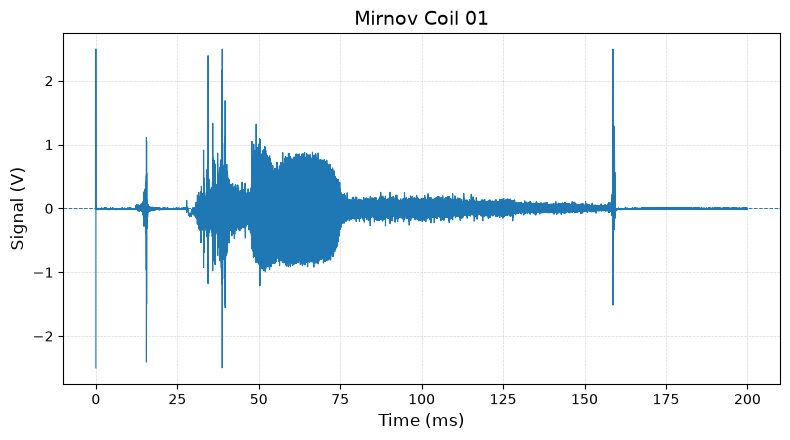

In [72]:
no_mirnov = r"\TCABR_SHOT::TOP.ACQSIGNALS.BBMRNVN01.signal"

time, signal = channel_load(33668, no_mirnov)

plt.figure(figsize=(8, 4.5))

plt.xlabel("Time (ms)", fontsize=12)
plt.ylabel("Signal (V)", fontsize=12)
plt.title(r"Mirnov Coil 01", fontsize=14)
plt.plot(time, signal, linewidth=0.8)
plt.axhline(0, linewidth=0.7, linestyle="--")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

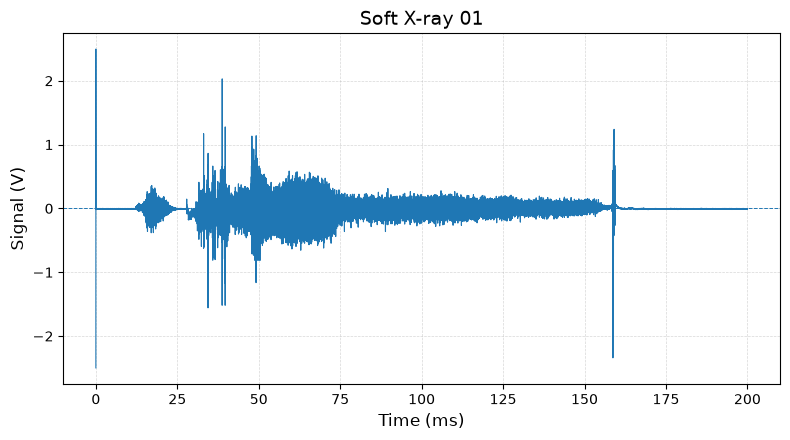

In [73]:
no_sxr= r"\TCABR_SHOT::TOP.ACQSIGNALS.SOFTXR001.signal"

time, signal = channel_load(33668, no_sxr)

plt.figure(figsize=(8, 4.5))

plt.xlabel("Time (ms)", fontsize=12)
plt.ylabel("Signal (V)", fontsize=12)
plt.title("Soft X-ray 01", fontsize=14)
plt.plot(time, signal, linewidth=0.8)
plt.axhline(0, linewidth=0.7, linestyle="--")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

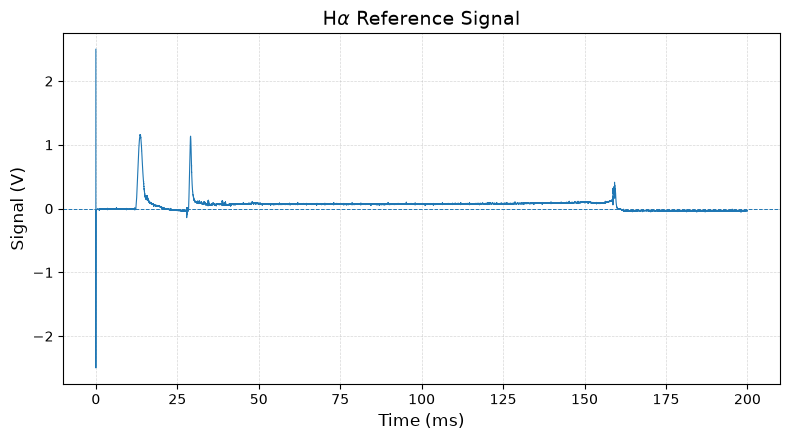

In [74]:
no_halpha= r"\TCABR_SHOT::TOP.ACQSIGNALS.HALFAREF0.signal"

time, signal = channel_load(33668, no_halpha)

plt.figure(figsize=(8, 4.5))

plt.xlabel("Time (ms)", fontsize=12)
plt.ylabel("Signal (V)", fontsize=12) 
plt.title(r"H$\alpha$ Reference Signal", fontsize=14)
plt.plot(time, signal, linewidth=0.8)
plt.axhline(0, linewidth=0.7, linestyle="--")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()